# <b>1 <span style='color:#F1A424'>|</span>시계열 데이터 처리를 위한 넘파이 및 판다스 기능 </b> 

- 날짜 : 2026-06-19(금요일)
<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color: #f13c24'>핵심 개념 및 내용</span></b></p></div>

1. python, numpy, pandas : 날짜 타입 비교 및 정리
2. key numpy data types
3. pandas의 timestatmp처리
4. pandas의 datetime index를 가지고

Resample : 시간 간격을 재조정

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 시각화 세팅 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16,4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("모든 라이브러리 임포트 완료입니다")

## <div style="color:white;display:fill;border-radius:8px;background:linear-gradient(135deg,#6366f1,#8b5cf6);font-size:60%; letter-spacing:1.0px"><p style="padding:8px 14px;color:white;box-shadow:0 2px 8px rgba(99,102,241,0.25);"><b><b><span style='color:white'></span></b> 날짜 데이터 정의_ 라이브러리</b></p></div>

### 1. Python 내장 datetime 라이브러리

In [ ]:
import datetime

print(datetime.date(2022,3,1))

print(datetime.datetime(2026,5,1,15,30,27))

print(datetime.time(15,30,55))

2022-03-01
2026-05-01 15:30:27
15:30:55


### 2. Numpy의 datetime

In [ ]:
import numpy as np

print(np.datetime64("2022-05-12"))

2022-05-12


###  3. Pandas의 datetime

In [ ]:
import pandas as pd

df = pd.read_csv("data/superstore.csv", encoding="latin1")
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
time_stamp = pd.Timestamp(datetime(2026,1,1))

In [ ]:
print(time_stamp.year)
print(time_stamp.month)
print(time_stamp.day)
print(time_stamp.day_of_week)

2026
1
1
3


In [ ]:
period  = pd.Period('2026-01')
period 

Period('2026-01', 'M')

In [ ]:
period.to_timestamp()

Timestamp('2026-01-01 00:00:00')

In [ ]:
period.to_timestamp().to_period('M')

Period('2026-01', 'M')

In [ ]:
period= pd.Period('2026-01')

period+2

Period('2026-03', 'M')

pd.date_range()는 일정한 간격을 가진 날짜(DateTime)의 연속된 시퀀스를 생성하는 함수

```python
pd.date_range( start=None, end=None, periods=None, freq='D' )
```
- periods : 몇 개의 날짜를 만들 것인지
- freq : 얼마 간격으로 날짜를 생성할 것인지 
  - 'D' : 하루
  - 'W' : 1주
  - 'MS' : 매월 1일
  - 'ME' : 매월 끝날 
  - 'YS'/'YE'

In [ ]:
index = pd.date_range(start='2017-1-1', periods=12, freq='MS')
index

DatetimeIndex(['2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01',
               '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01',
               '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01'],
              dtype='datetime64[us]', freq='MS')

In [ ]:
df = pd.read_csv("data/Nice One Beauty Digital Marketing Company.csv")
df = df[['Date','Close']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    267 non-null    str    
 1   Close   267 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.3 KB


In [ ]:
# 1. str(object) to datetime64(시계열 기능 사용)
# 2. data 컬럼을 index로 지정하기 (더 쉽게 다루기 위해서)
df.Date = pd.to_datetime(df.Date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    267 non-null    datetime64[us]
 1   Close   267 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 4.3 KB


In [ ]:
df.set_index('Date', inplace=True)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 267 entries, 2025-01-08 to 2026-01-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   267 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


DatetimeIndex: 267 entries, 2025-01-08 to 2026-01-29 현재 이 데이터프레임의 인덱스는 숫자가 아니라 date이다. 

C:\Users\bongr\AppData\Local\Temp\ipykernel_16128\3442477252.py:2: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bongr\AppData\Local\Temp\ipykernel_16128\3442477252.py:2: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bongr\AppData\Local\Temp\ipykernel_16128\3442477252.py:2: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bongr\AppData\Local\Temp\ipykernel_16128\3442477252.py:2: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Data-Analysis-Study\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Data-Analysis-Study\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54000 

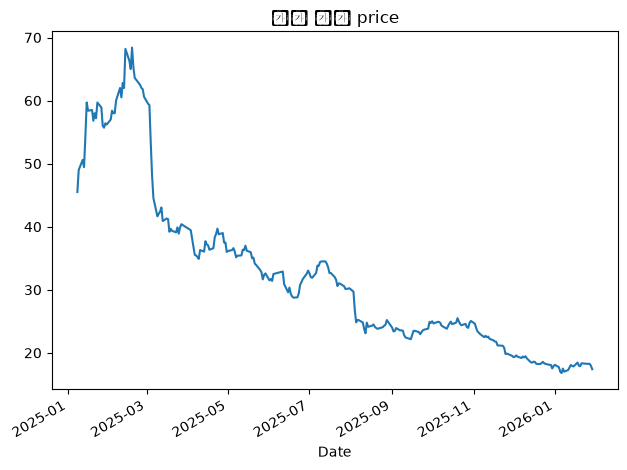

In [ ]:
df.Close.plot(title = "뷰티 기업 price")
plt.tight_layout()
plt.show()

In [ ]:
print(df.index)
print(df.index.min())
print(df.index.max())
print(df.info())

DatetimeIndex(['2025-01-08', '2025-01-09', '2025-01-12', '2025-01-13',
               '2025-01-14', '2025-01-15', '2025-01-16', '2025-01-19',
               '2025-01-20', '2025-01-21',
               ...
               '2026-01-18', '2026-01-19', '2026-01-20', '2026-01-21',
               '2026-01-22', '2026-01-25', '2026-01-26', '2026-01-27',
               '2026-01-28', '2026-01-29'],
              dtype='datetime64[us]', name='Date', length=267, freq=None)
2025-01-08 00:00:00
2026-01-29 00:00:00
<class 'pandas.DataFrame'>
DatetimeIndex: 267 entries, 2025-01-08 to 2026-01-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   267 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB
None


In [ ]:
# 특정 날짜 파셔
### 날짜 인덱싱 ( datetime indexing ) -> .loc(행번호)
### 날짜 인덱싱해서 기초 통계 확인하기 
df.loc['2025'].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 246 entries, 2025-01-08 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   246 non-null    float64
dtypes: float64(1)
memory usage: 3.8 KB


In [ ]:
# 특정 기간 동안 데이터 
df.loc['2025-3' : '2026-1'].info() # slice 포함함 : last month

<class 'pandas.DataFrame'>
DatetimeIndex: 231 entries, 2025-03-02 to 2026-01-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   231 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB


시계열 분석에서 모든 알고리즘의 가정 :   
**모든 날짜가 존재해야한다**

- asfreq('D') : 달력 기준으로 모든 날짜를 만들어라   
- 해당 날짜가 없었다면 특성값에는 nan이 들어간다
-  즉 시간축(time axis)를 일정하게 만들어줌 

In [ ]:
# 빈 날짜 채우기
df.asfreq('D').info() # set calendar day frequency


<class 'pandas.DataFrame'>
DatetimeIndex: 387 entries, 2025-01-08 to 2026-01-29
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   267 non-null    float64
dtypes: float64(1)
memory usage: 6.0 KB


In [ ]:
df.asfreq('D').head() # NaN 

,Close
Date,
2025-01-08,45.500000
2025-01-09,49.000000
2025-01-10,NaN
2025-01-11,NaN
2025-01-12,50.599998


#### shift() 
 moving data between past & future

- default : one preiod into the future
- by giving the periods variable the desired shift value.
- LAG : 과거값

In [ ]:
df['shifted'] = df.Close.shift() # default : period = 1
df.head()
# close : 오늘 종가, shifted : 어제 종가 = 즉 어제 가격을 오늘과 비교하기 위한 작업

,Close,shifted
Date,,
2025-01-08,45.500000,NaN
2025-01-09,49.000000,45.500000
2025-01-12,50.599998,49.000000
2025-01-13,49.450001,50.599998
2025-01-14,54.299999,49.450001


In [ ]:
# periods = -1 /미래 값을 현재 행으로 가져옴
df['lagged'] = df.Close.shift(periods=-1)
df[['Close', 'lagged', 'shifted']].tail(3)
# 마지막 날짜의 lagged 값의 경우 즉 미래값이 없으므로 nan


,Close,lagged,shifted
Date,,,
2026-01-27,18.26,17.98,18.25
2026-01-28,17.98,17.40,18.26
2026-01-29,17.40,NaN,17.98


#### percentage change 

: 전일 대비 얼만 올랐는가 ? 

- shift () : 어제 가격
- div () : 오늘 가격 / 어제 가격(shift)
- sub(1) : (오늘 가격 / 어제 가격) - 1
- mul(100) : 단위 변환 (%)

In [ ]:
df['change'] = df.Close.div(df.shifted) # 오늘 값 / 어제값  변화량
df['return'] = df.change.sub(1).mul(100) # 1- 변화량을 뺀 값 * 100 = 퍼센티지
df[['Close','shifted','change','return']].head(3)

# 첫날의 경우 전날 값이 없으니 변화를 비교할 값x, 변화량도 없음.

,Close,shifted,change,return
Date,,,,
2025-01-08,45.500000,NaN,NaN,NaN
2025-01-09,49.000000,45.5,1.076923,7.692308
2025-01-12,50.599998,49.0,1.032653,3.265303


In [ ]:
df.Close.pct_change()

Date
2025-01-08         NaN
2025-01-09    0.076923
2025-01-12    0.032653
2025-01-13   -0.022727
2025-01-14    0.098079
                ...   
2026-01-25   -0.003275
2026-01-26   -0.000548
2026-01-27    0.000548
2026-01-28   -0.015334
2026-01-29   -0.032258
Name: Close, Length: 267, dtype: float64

In [ ]:
df['pct_change'] = df.Close.pct_change().mul(100) # 퍼센티지로
df[['Close', 'return', 'pct_change']].head(3) # 계산 로직을 함수로 제공

,Close,return,pct_change
Date,,,
2025-01-08,45.500000,NaN,NaN
2025-01-09,49.000000,7.692308,7.692308
2025-01-12,50.599998,3.265303,3.265303


In [ ]:
# pct_change()의 기본값 : 1 즉 어제 대비 오늘 몇%가 변했는가 
# periods = 3 : 3일 전과 비교 period 값만큼 처음 날짜에 nan 결측이 생김
df['return_3d'] = df.Close.pct_change(periods=3).mul(100)

df[['Close','return', 'return_3d']].head()


,Close,return,return_3d
Date,,,
2025-01-08,45.500000,NaN,NaN
2025-01-09,49.000000,7.692308,NaN
2025-01-12,50.599998,3.265303,NaN
2025-01-13,49.450001,-2.272723,8.681320
2025-01-14,54.299999,9.807884,10.816325


#### Basic Time Series Metrics & Resampling

- Resampling(리샘플링) : 시계열 데이터의 시간 단위(freq)를 변경하는 작업 
  - 즉 현재 데이터(daily) ➔ 월별 데이터(monthly)
  - 시간 단위를 맞췅 비교하기 위한 작업
- Upsampling : 낮은 빈도(분기 / 월) ➔ 높은 빈도(월 / 일)
  - but 날짜가 많이 생김 -> 원래 없던 데이터 ➔ 대부분 Nan
  - NaN 채우기 .
    - ffill() : 앞의 값으로 채우기
- Downsampling : 높은 빈도(일별) → 낮은 빈도(월별)
  - 보통 데이터 집계 : mean, sum, max,min 등을 사용함
  - 데이터 수가 줄어듬

In [ ]:
# Creating 분기 데이터

dates = pd.date_range(start='2025', periods=4, freq='QE')
data = range(1,5)

quarterly = pd.Series(data=data, index = dates)
quarterly

2025-03-31    1
2025-06-30    2
2025-09-30    3
2025-12-31    4
Freq: QE-DEC, dtype: int64

In [ ]:
# UP-Sampling : quarterly to monthly using dot-asfreq()
# add new month - end data

monthly = quarterly.asfreq('ME')
monthly = monthly.to_frame('baseline')
monthly

,baseline
2025-03-31,1.0
2025-04-30,NaN
2025-05-31,NaN
2025-06-30,2.0
2025-07-31,NaN
2025-08-31,NaN
2025-09-30,3.0
2025-10-31,NaN
2025-11-30,NaN
2025-12-31,4.0


In [ ]:
# fill missing values when upsampling
# 1. fill method 사용하기
# 2. forward fill or back fill
# 3. full value 제공하기

# different upsampling fill methods
#ffill : forward fill
monthly['ffill'] = quarterly.asfreq('ME', method='ffill') 

# back fill : bfill
monthly['bfill'] = quarterly.asfreq("ME", method='bfill')

# fill value
monthly['value'] = quarterly.asfreq("ME", fill_value=0) # 채울 값을 지정

monthly

,baseline,ffill,bfill,value
2025-03-31,1.0,1,1,1
2025-04-30,NaN,1,2,0
2025-05-31,NaN,1,2,0
2025-06-30,2.0,2,2,2
2025-07-31,NaN,2,3,0
2025-08-31,NaN,2,3,0
2025-09-30,3.0,3,3,3
2025-10-31,NaN,3,4,0
2025-11-30,NaN,3,4,0
2025-12-31,4.0,4,4,4


In [ ]:
dates = pd.date_range(start='2025', periods=12, freq='ME')
dates

DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31',
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31'],
              dtype='datetime64[us]', freq='ME')

In [ ]:
quarterly

2025-03-31    1
2025-06-30    2
2025-09-30    3
2025-12-31    4
Freq: QE-DEC, dtype: int64

In [ ]:
quarterly.reindex(dates) # 지정한 날짜로 새로운 인덱스로 사용해
# 원래 존재하던 값은 그대로 들어가고 
# 새롭게 추가된 날짜는 nan이 됨. 

2025-01-31    NaN
2025-02-28    NaN
2025-03-31    1.0
2025-04-30    NaN
2025-05-31    NaN
2025-06-30    2.0
2025-07-31    NaN
2025-08-31    NaN
2025-09-30    3.0
2025-10-31    NaN
2025-11-30    NaN
2025-12-31    4.0
Freq: ME, dtype: float64

In [ ]:
# reindex의 결측치 채우기
quarterly.reindex(dates, method='ffill')

2025-01-31    NaN
2025-02-28    NaN
2025-03-31    1.0
2025-04-30    1.0
2025-05-31    1.0
2025-06-30    2.0
2025-07-31    2.0
2025-08-31    2.0
2025-09-30    3.0
2025-10-31    3.0
2025-11-30    3.0
2025-12-31    4.0
Freq: ME, dtype: float64

In [ ]:
quarterly.reindex(dates, method='bfill')

2025-01-31    1
2025-02-28    1
2025-03-31    1
2025-04-30    2
2025-05-31    2
2025-06-30    2
2025-07-31    3
2025-08-31    3
2025-09-30    3
2025-10-31    4
2025-11-30    4
2025-12-31    4
Freq: ME, dtype: int64

#### asfreq()와 reindex()의 차이

- asfreq() : 시간의 빈도(freq)를 변경하는 함수 ➔ 시간의 간격을 바꾸는 게 목적 
  - 시계열의 빈도(Frequency)를 바꾸는 함수
- reindex() : 내가 원하는 인덱스에 맞춰 데이터를 재배치
  - 날짜 뿐만 아니라, 숫자, 문자열 어디에도 사용 가능 
  - 시계열 전용x, 일반적인 인덱스 조정
  - 내가 원하는 인덱스 목록에 맞춰 다시 배열해줘.
  
**resample() = groupby()처럼 동작한다**

- groupby() : 원하는 그룹을 묶은 뒤 집계함.
- resample() : 시간(Time) 으로 그룹을 만든다 


## 4. Sationary(정상성) | 정상 시계열 데이터의 이해

정상 시계열(Stationary Time Series)
- 시간이 지나도 데이터의 통계적 성질이 변하지 않는 시계열 
- 고전적인 시계열 모델(통계적 기반) 미래도, 과거와 같은 통계적 성질을 가진다.
- 즉 평균도 변하고, 분산도 변하고, 패턴(주기성) 등도 계속 변동된다면 과거 데이터를 이용해 미래를 예측하기는 어려워짐
-  그래서 실제 분석에서는 비정상 시계열를 정상 시계열에 가깝게 만든 뒤 모델을 학습
   -  추세 제거 (Differencing)
   -  로그 변환 (Log Transform)
   -  계절성 제거 (Seasonal Differencing)

**특징**
1. 일정한 평균 (constant mean)
   1. 시간이 지나도 평균이 100에 계속 머무는 것 vs 시간이 지날 수록 가격이 오르는 것 -> 가격의 평균도 상승 (추세_trend)가 존재.
2. 일정한 분산 (constant variance)
   1. 데이터가 퍼져있는 정도(변동폭)이 일정한 것 
3. 일정한 자기 상관성(constant auto corr structure) 
   1. 자기상관성 (Autocorrelation) : 과거 데이터와 현재 데이터가 얼마나 관련있는가
   2. "과거가 현재에 미치는 영향이 시간에 따라 달라지지 않아야 한다."
4. No Periodic Component (주기성이 없어야 함)
   1. 주기적인 패턴(Seasonality)이 있으면 정상성이 깨질 수 있음.

5. 정상성에 대한 이해
6. 자기 상관 구조
7. 비정상성에 대한 이해
8. Diffencing
9.  자기 상관성을 시각화하는 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 시각화 세팅 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16,4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("모든 라이브러리 임포트 완료입니다")

모든 라이브러리 임포트 완료입니다


In [22]:
np.random.seed(101)

time = np.arange(500)
stationary = np.random.normal(loc=0, #location : 평균(0)->정규분포
                              scale=1.0, # scale : 표준편차(1) 
                              size=len(time)
                              )

print(time.shape)
print(stationary.shape)

(500,)
(500,)


In [23]:
# 시각화 하기
def plot_sequence(x,y,title:str):
    plt.plot(x, y)
    plt.xlabel("time")
    plt.ylabel("series value")
    plt.title(title)
    plt.grid(alpha=0.6)
    plt.show()

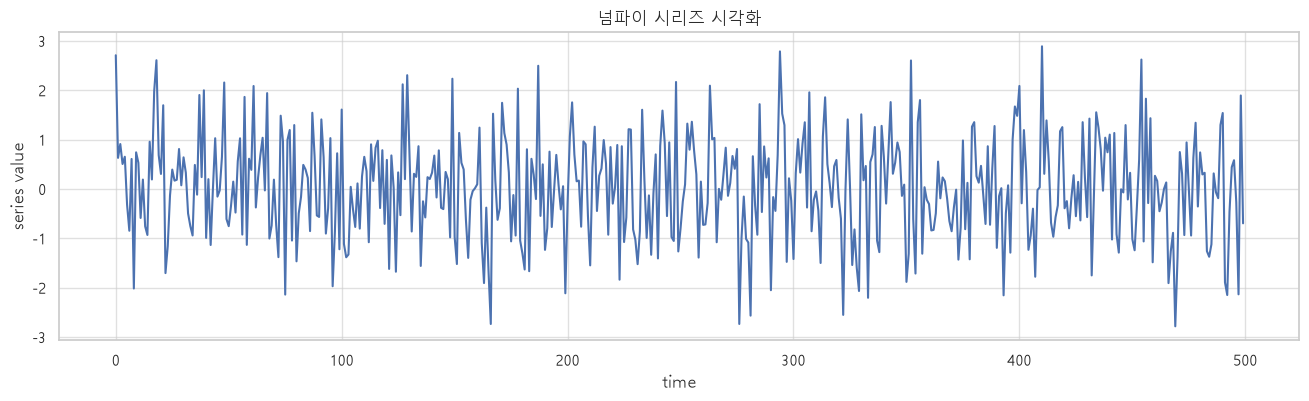

In [ ]:
plot_sequence(time, stationary,"넘파이 시리즈 시각화")
# 4가지 정상성 조건 충족
## 1. 일정한 평균 : 0
## 2. 일정한 분산 : scale = 1
## 3. 일정한 자기상관
## 4. 주기성분 x
# 시계열의 histogram을 plot -> 정규분포를 보이면 평균과 분산이 일정하다 

<Axes: >

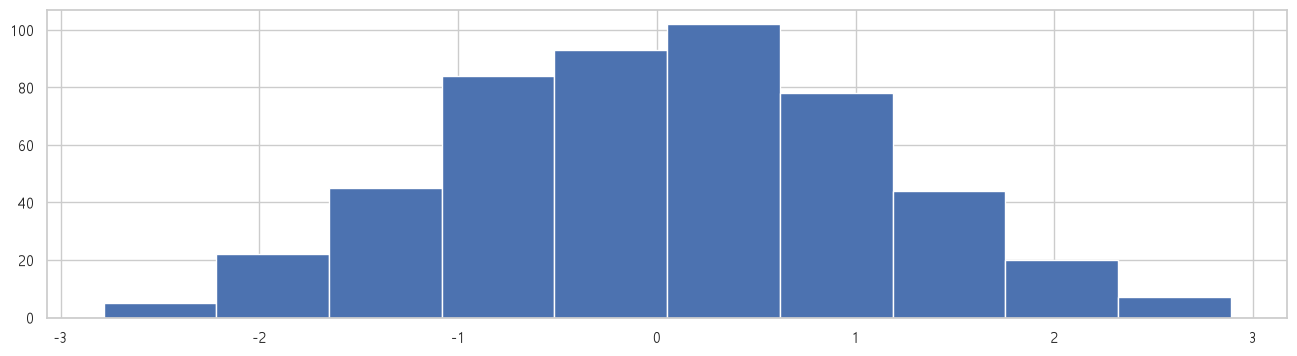

In [ ]:
# 판다스의 경우 히스토그램 plot 기능을 내장하고 있음 
pd.Series(stationary).hist() 

## 자기 상관 구조 (AutoCorrelation Structure)
- 특정 시점(step)이 다른 시점(step)과 수치적 연관성이 있따.
- 자기 상관성은 차분(difference)에 의해 정상성 전환 가능 
- 시계열이 

In [38]:

# 반환 타입 : array : 배열 
print(np.random.normal(loc=0, scale=2.5, size=1))
a =np.random.normal(loc=0, scale=2.5, size=1)
print(type(a))

#1. array에서 float만 꺼내기 : .item()
print(np.random.normal(loc=0, scale=2.5, size=1).item())

#2. array에서 첫번째 원소만 꺼내기 = [0]
print(np.random.normal(loc=0, scale=2.5, size=1)[0])

#3. size 빼기
print(np.random.normal(loc=0, scale=2.5))

[-0.19913923]
<class 'numpy.ndarray'>
-2.5624578432725342
-0.5672724128643177
3.261700643085362


In [ ]:
seed=3.14
#empty_like : 걍 아무 값이나 채워라 
seed=3.14
lagged = np.empty_like(time,dtype="float32")
print(time.shape)
print(lagged.shape)
# t: 0~499
for t in time:
    lagged[t] = seed + np.random.normal(loc=0, scale=2.5)
    seed = lagged[t] #업데이트된 값

(500,)
(500,)
np.random.normal(loc=0, scale=2.5, size=1) : array([0.05223742])


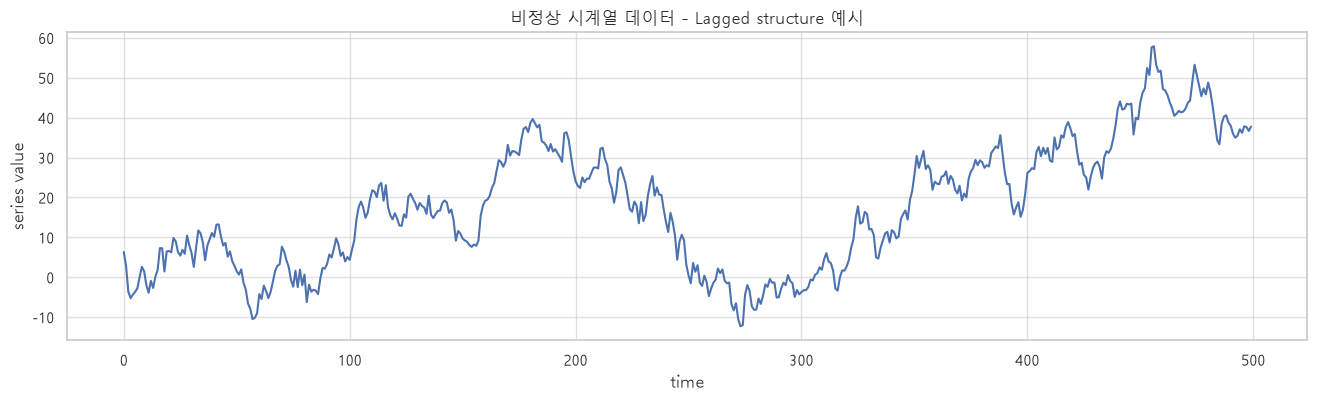

In [ ]:
plot_sequence(time,lagged, "비정상 시계열 데이터 - Lagged structure 예시")

**Non-stationary 해석**
- 일정한 자기 상관 구조가 없음 -> 방향성이 왔다갓다함.
- 불규칙. 
- 히스토그램을 그렸을 때도 정규분포가 아님(비정규분포)  = 즉 시계열이 균일하게 분포되어 있을 경우 비정상 데이터다

<Axes: >

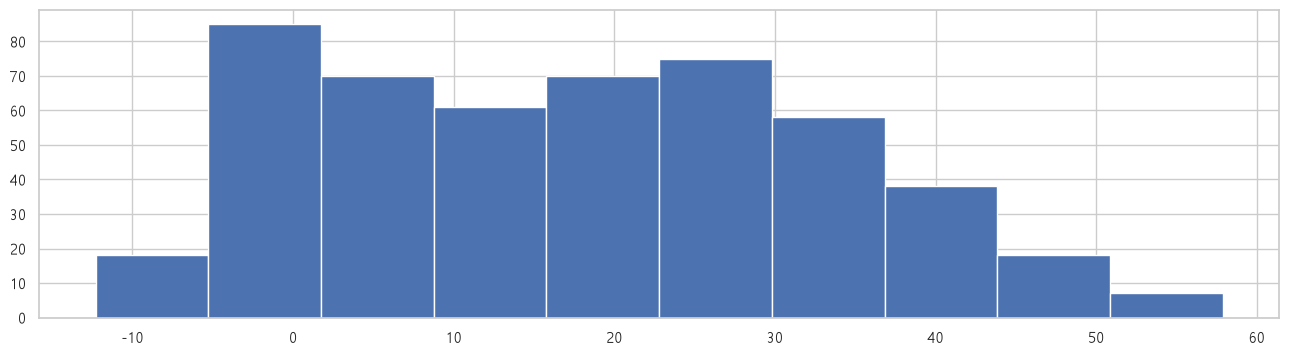

In [40]:
pd.Series(lagged).hist()

**Non-stationary의 추세(Trend)**
- 평균이 시간이 지남에 따라 변화 

stationary 구조

```python
stationary = np.random.normal(loc=0, #location : 평균(0)
                              scale=1.0, # 표준편차(1) 
                              size=len(time)
                              )
```

변화가 없는 stationary 를 가지고 time 에 더해주게 되면.<br>
time이 증가하면 trend 증가. 

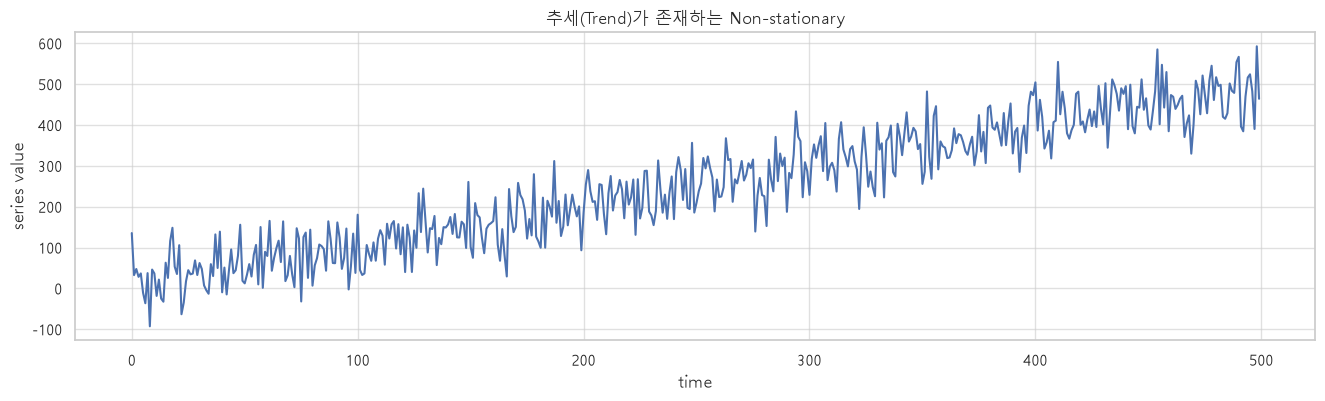

In [ ]:
trend = time + stationary*50 
plot_sequence(time, trend, "추세(Trend)가 존재하는 Non-stationary" )

# 평균값이 시간이 지남에 따라 같이 계속 올라감 

### 이분산성(변동 분산)
시간에 따른 분산의 변화 

In [ ]:
np.random.seed(123)

level_1 = np.random.normal(0,1.0,size=250)
level_2 = np.random.normal(0,10.0,size=250)

data = np.append(level_1, level_2)

print(data.shape)

(500,)


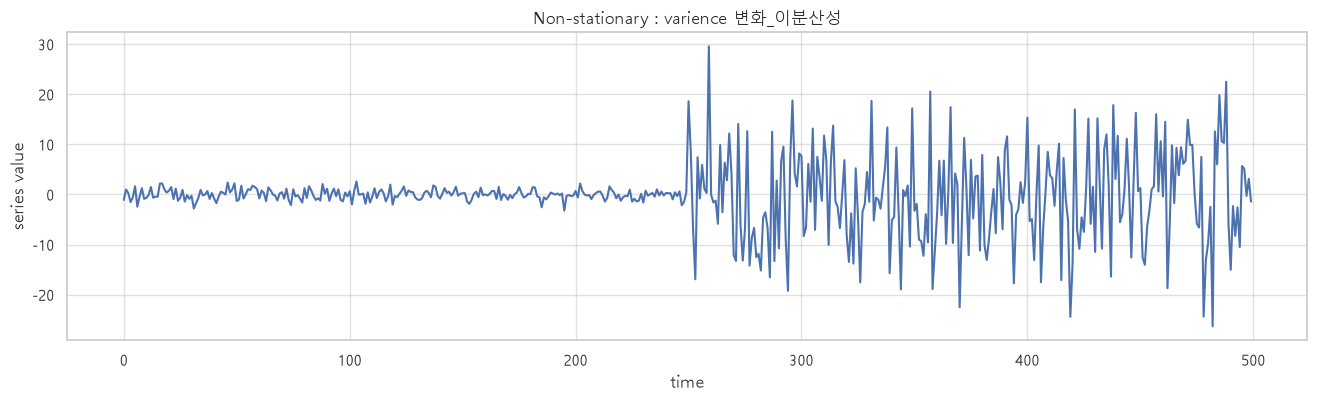

In [ ]:
plot_sequence(time, data, "Non-stationary : varience 변화_이분산성")

# 평균은 두 파트 모두 0으로 같음에도 분산의 차이 존재 
# 주식시장에서 말하는 리스크 = 변동성 = 분산의 차이가 얼마나 커졌는가
# 표준편차가 작은 상태 = 변동성이 작다
# 표준편차가 커진 상태 = 변동성이 커진 

### Seasonality 
주기적인 요소가 존재하면 non-stationary

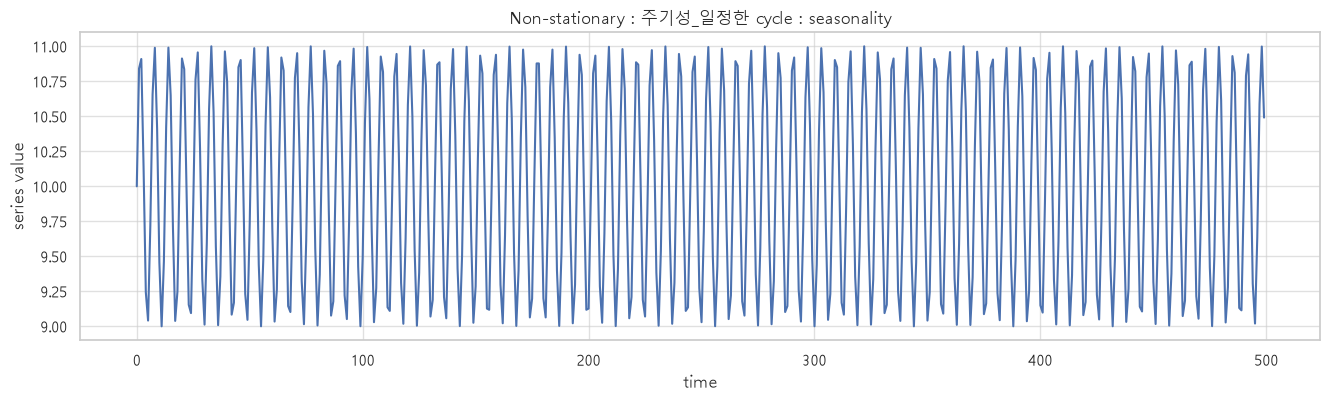

In [46]:
seasonality = 10 + np.sin(time) # 시간에 따라 싸이클을 그림 _+ 싸인 주기함수
plot_sequence(time,seasonality, "Non-stationary : 주기성_일정한 cycle : seasonality")

### 복합적인 Non-stationarity : Trend + 주기성

- 평균이 시간이 지남에 따라 변하고 (Trend)가 존재
- 주기적인 구성요소가 존재 (Sesonality)

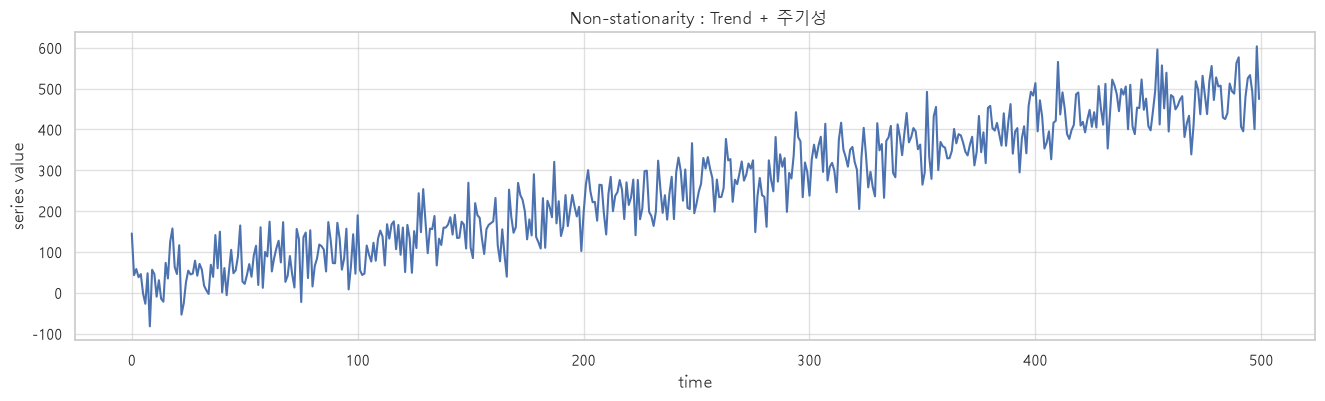

In [47]:
trend_seasonality = trend + seasonality
plot_sequence(time, trend_seasonality," Non-stationarity : Trend + 주기성")

### 복합적인 Non-stationarity : Trend + Autocorr

- autocorr : 원래 정상성 데이터는 정규분포를 띄어야하는데 auto의 경우 시계열이 균일하게 분포를 함.

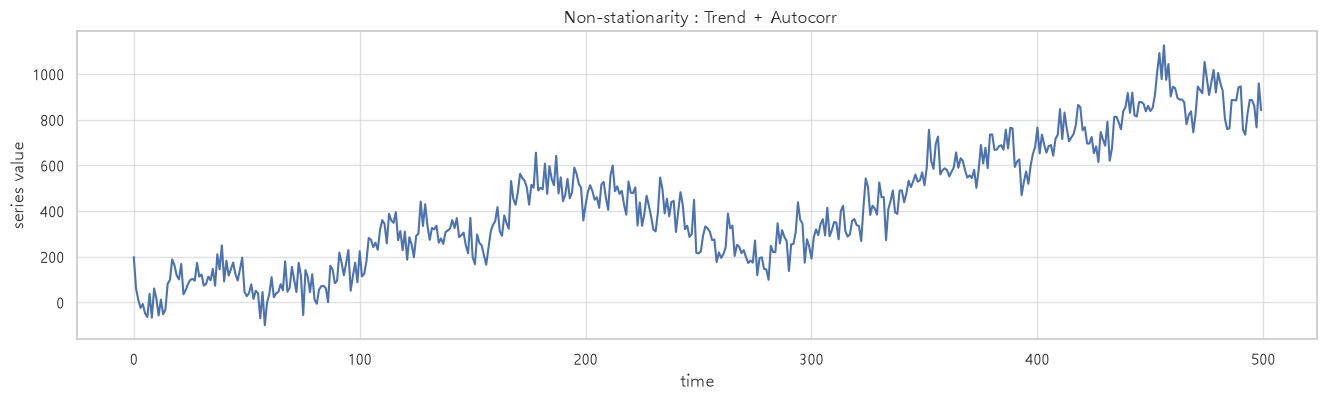

In [48]:
auto_corr_trend = lagged*10 + trend
plot_sequence(time, auto_corr_trend," Non-stationarity : Trend + Autocorr")

In [50]:
time2 = np.arange(time.size*2) 
print(time2.shape)

(1000,)


In [53]:
trend2 = -time + stationary*50
trend2

# 시간이 증가함에 따라 = 음수값이 커지고 
# 거기에 더해지는 값은 거의 일정함
# 즉 계속 파국 

array([ 135.34249197,   30.40663544,   43.39847232,   22.19128769,
         28.5558974 ,  -20.96590223,  -48.40384917,   23.29826747,
       -108.9084122 ,   28.00610285,   16.4406747 ,  -40.45002666,
         -2.56523453,  -50.94360281,  -60.66186082,   32.75282546,
         -6.46028388,   81.93786621,  112.29836399,   15.17544428,
         -4.86672757,   63.68614626, -107.30429654,  -80.95597078,
        -30.74203603,   -5.47360786,  -17.6547682 ,  -17.77490704,
         12.38529571,  -25.35201623,    1.93935067,  -14.51768506,
        -56.85520114,  -70.70348505,  -81.17032016,  -10.76241764,
        -41.83866582,   58.08773976,  -26.09365206,   60.83261427,
        -89.663175  ,  -31.16002475,  -98.83222968,  -42.98167602,
          7.2992076 ,  -52.82989521,  -47.5789572 ,  -14.50870833,
         59.74232216,  -79.51294279,  -87.766267  ,  -68.32092518,
        -44.64866143,  -76.97240195,  -26.06152968,   -3.75948608,
       -102.29371294,   36.14320692, -114.69085808,  -28.47610

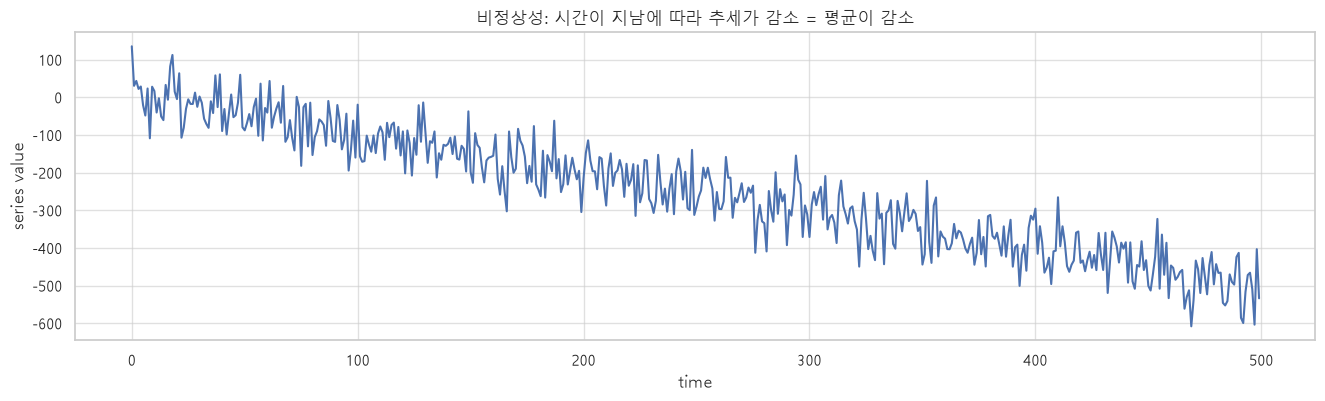

In [55]:
plot_sequence(time, trend2, "비정상성: 시간이 지남에 따라 추세가 감소 = 평균이 감소")

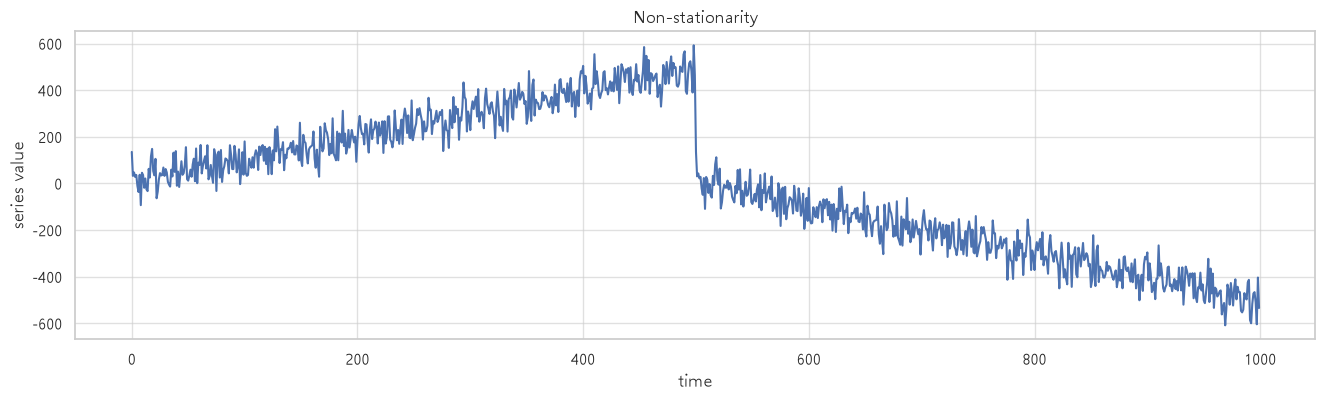

In [ ]:
trend2_down = -time + stationary*50 # 시간이 지날 수록 주가 감소
trend1_rise = time + stationary*50 # 시간이 지남에 따라 주가 증가

# 금융 위기 : 주가 떡락 
financial_crisis = np.append(trend1_rise, trend2_down)

plot_sequence(time2, financial_crisis, " Non-stationarity : financial_crisis ")

### Differencing 으로 auto corr 제거하기

- 각 데이터 포인트가 i